In [1]:
# Cell A1 — 环境与路径
import os, gc, h5py, numpy as np
from collections import Counter

# 结果与标注文件所在目录
Export_FolderName = "ProcessingTest"

# 选用哪组片段作为输入：'filtered' 用 all_peak_segments_marking.h5；
# 用 'prefilt' 可改为 all_peak_segments_prefilt_marking.h5（不确定建议先用 filtered）
USE_SEGMENTS = 'filtered'  # 'filtered' or 'prefilt'

SEG_FILE = {
    'filtered': os.path.join(Export_FolderName, "all_peak_segments_marking.h5"),
    'prefilt' : os.path.join(Export_FolderName, "all_peak_segments_prefilt_marking.h5"),
}[USE_SEGMENTS]

LABEL_FILE   = os.path.join(Export_FolderName, "all_clusters_marking.h5")
DATAPOINT_FILE = os.path.join(Export_FolderName, "all_peak_datapoint_marking.h5")

os.makedirs(Export_FolderName, exist_ok=True)
print("Using segments:", SEG_FILE)
print("Labels:", LABEL_FILE)
print("Datapoints:", DATAPOINT_FILE)

Using segments: ProcessingTest/all_peak_segments_marking.h5
Labels: ProcessingTest/all_clusters_marking.h5
Datapoints: ProcessingTest/all_peak_datapoint_marking.h5


In [2]:
# Cell A2 — 读取 H5（片段/标签/位置），对齐校验与聚合
import h5py
import numpy as np

def load_segments_list(h5_path, dataset_key=None):
    """
    读取形如：
    file['all_peak_segments'] 是 group，下面每个 key（'0','1',...）是一组变长 1D 波形（长度应为60）
    统一转为 Python 列表：list[ channel ] -> list[ spike ] -> np.array(60,)
    """
    segs_by_ch = []
    with h5py.File(h5_path, 'r') as hdf:
        # 自动探测根下唯一 group（常见命名 'all_peak_segments_marking' 或 'all_peak_segments'）
        if dataset_key is None:
            # 若根下只有一个组，就用它；否则尝试常见名
            keys = list(hdf.keys())
            if len(keys) == 1:
                grp = hdf[keys[0]]
            else:
                # 兜底尝试两种常用命名
                for k in ["all_peak_segments_marking", "all_peak_segments", "segments"]:
                    if k in hdf:
                        grp = hdf[k]
                        break
                else:
                    raise KeyError(f"未找到 segments group，根键有：{keys}")
        else:
            grp = hdf[dataset_key]

        # 通道按 key 排序（'0','1',...）
        ch_keys = sorted(grp.keys(), key=lambda x: int(x))
        for ch in ch_keys:
            dset = grp[ch]
            # dset 是可迭代，成员为 1D 波形
            seg_list = [np.array(d) for d in dset]
            segs_by_ch.append(seg_list)
    return segs_by_ch

def load_vector_list(h5_path, key_guess):
    """
    读取 labels/datapoints：根下 dataset 名可能为 key_guess，也可能恰好只有一个 dataset。
    返回 list[ channel ] -> np.array(n_spikes,)
    """
    out = []
    with h5py.File(h5_path, 'r') as hdf:
        if key_guess in hdf:
            dset = hdf[key_guess]
        else:
            keys = list(hdf.keys())
            if len(keys) == 1:
                dset = hdf[keys[0]]
            else:
                raise KeyError(f"未找到 {key_guess}；根键有：{keys}")
        # dset 形如 (n_channels,) 每个元素是变长向量
        for i in range(len(dset)):
            out.append(np.array(dset[i]))
    return out

# 读取
segments = load_segments_list(SEG_FILE)
labels   = load_vector_list(LABEL_FILE,    key_guess="all_clusters_marking")
datapts  = load_vector_list(DATAPOINT_FILE,key_guess="all_peak_datapoint_marking")

# 基本一致性检查
n_ch_seg, n_ch_lbl, n_ch_dp = len(segments), len(labels), len(datapts)
print(f"channels: seg={n_ch_seg}, lbl={n_ch_lbl}, dp={n_ch_dp}")

# 逐通道数量对齐检查
bad = []
for ch in range(min(n_ch_seg, n_ch_lbl, n_ch_dp)):
    a, b, c = len(segments[ch]), len(labels[ch]), len(datapts[ch])
    if not (a == b == c):
        bad.append((ch, a, b, c))
        print(f"数量不对齐: ch{ch} seg={a}, lbl={b}, dp={c}")
if not bad:
    print("各通道数量对齐 OK")

# 聚合为大数组：X_full (N, 60), y_full (N,), pos_full (N,2)
X_list, y_list, pos_list = [], [], []
empty_channels = []
for ch in range(len(segments)):
    seg_ch, lab_ch, dp_ch = segments[ch], labels[ch], datapts[ch]
    if len(seg_ch) == 0 or len(lab_ch) == 0:
        empty_channels.append(ch)
        continue
    assert len(seg_ch) == len(lab_ch) == len(dp_ch), f"通道{ch}数量不对齐"

    # 丢弃 label==100（不确定）
    mask = lab_ch != 100
    seg_use = np.asarray(seg_ch, dtype=object)[mask]
    lab_use = lab_ch[mask]
    dp_use  = dp_ch[mask]
    if len(seg_use) == 0:
        empty_channels.append(ch)
        continue

    # 堆成 (n_spikes, 60)
    seg_arr = np.stack(seg_use).astype(np.float32)
    X_list.append(seg_arr)
    y_list.append(lab_use.astype(np.int64))
    pos_list.append(np.stack([np.full_like(dp_use, ch), dp_use], axis=1))

X_full = np.concatenate(X_list, axis=0)
y_full = np.concatenate(y_list, axis=0)
pos_full = np.concatenate(pos_list, axis=0)

print(f"最终形状: X={X_full.shape} y={y_full.shape} pos={pos_full.shape}")
print("Label 分布:", dict(Counter(y_full.tolist())))
if empty_channels:
    print("空通道（跳过）:", empty_channels)

channels: seg=240, lbl=240, dp=240
各通道数量对齐 OK
最终形状: X=(76239, 60) y=(76239,) pos=(76239, 2)
Label 分布: {1: 17228, 0: 2336, 2: 56675}
空通道（跳过）: [0, 7, 12, 14, 15, 16, 21, 25, 27, 30, 31, 32, 33, 36, 41, 50, 51, 53, 54, 55, 56, 57, 59, 60, 62, 63, 64, 67, 68, 69, 70, 71, 72, 73, 74, 75, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 121, 124, 125, 136, 137, 139, 140, 141, 142, 143, 144, 147, 148, 149, 150, 151, 154, 160, 161, 162, 163, 164, 167, 168, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 195, 196, 199, 202, 208, 212, 213, 214, 215, 217, 218, 219, 221, 222, 223, 225, 226, 229]


In [ ]:
# Cell A3 — 任务切分与保存（Task A：噪声vs信号；Task B：皮层vs脊髓）
from sklearn.model_selection import train_test_split
from collections import Counter
import numpy as np, os

def stratified_split_indices(y, train=0.7, val=0.15, test=0.15, random_state=42):
    idx = np.arange(len(y))
    tr_idx, tmp_idx, y_tr, y_tmp = train_test_split(idx, y, train_size=train,
                                                    stratify=y, random_state=random_state)
    val_ratio = val / (val + test)
    val_idx, te_idx, _, _ = train_test_split(tmp_idx, y_tmp,
                                             train_size=val_ratio,
                                             stratify=y_tmp,
                                             random_state=random_state)
    return tr_idx, val_idx, te_idx


# ---------------------------------------------------------
# 🔥 Task A：0=噪声, 100=噪声, 1=信号, 2=信号 → 二分类
# ---------------------------------------------------------
# 修改点：把 label==100 放入噪声类
yA = np.zeros_like(y_full)

# 0 和 100 → 0（噪声）
yA[(y_full == 0) | (y_full == 100)] = 0

# 1 和 2 → 1（信号）
yA[(y_full == 1) | (y_full == 2)] = 1

Xa = X_full.copy()

# 分割
trA, vaA, teA = stratified_split_indices(yA, 0.7, 0.15, 0.15, random_state=42)



# ---------------------------------------------------------
# 🔥 Task B：区分 1 vs 2（忽略 0 和 100）
# ---------------------------------------------------------
mask_B = np.isin(y_full, [1, 2])
Xb = X_full[mask_B]
yb = y_full[mask_B].copy()

# 重映射：1 → 0（皮层），2 → 1（脊髓）
yb[yb == 1] = 0
yb[yb == 2] = 1

# 分割
trB, vaB, teB = stratified_split_indices(yb, 0.7, 0.15, 0.15, random_state=42)



# ---------------------------------------------------------
# 保存
# ---------------------------------------------------------
np.savez_compressed(os.path.join(Export_FolderName, "taskA_data.npz"),
                    X=Xa, y=yA, tr=trA, val=vaA, te=teA)

np.savez_compressed(os.path.join(Export_FolderName, "taskB_data.npz"),
                    X=Xb, y=yb, tr=trB, val=vaB, te=teB)

print("Task A sizes:", len(trA), len(vaA), len(teA),
      "  分布:", dict(Counter(yA.tolist())))

print("Task B sizes:", len(trB), len(vaB), len(teB),
      "  分布:", dict(Counter(yb.tolist())))

Task A sizes: 53367 11436 11436   分布: {1: 73903, 0: 2336}
Task B sizes: 51732 11085 11086   分布: {0: 17228, 1: 56675}


In [4]:
# Cell A4 — 定义 1D ResNet + 训练工具（替换原来的 SpikeCNN1D 版本）

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np, os

# -------------------- 设备选择 --------------------
def pick_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

device = pick_device()
print("Using device:", device)


# -------------------- 1D ResNet 基本残差块 --------------------
class BasicBlock1D(nn.Module):
    """
    ResNet 风格的 1D 基本残差块：
    Input:  (B, C_in, L)
    Output: (B, C_out, L or L/2), 视 stride 而定
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm1d(out_channels)

        # 如果通道数 or 步长不匹配，用 1x1 conv 做下采样
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )
        else:
            self.downsample = None

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out, inplace=True)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(identity)

        out = out + identity
        out = F.relu(out, inplace=True)
        return out


# -------------------- 1D ResNet 主干网络 --------------------
class ResNet1D_Spike(nn.Module):
    """
    轻量版 1D ResNet，用于 spike 波形分类：
    输入: (B, 1, 60)

    结构：
    - STEM: Conv(1->32) + BN + ReLU
    - layer1: BasicBlock1D(32 -> 32, stride=1)   # 长度 60
    - layer2: BasicBlock1D(32 -> 64, stride=2)   # 长度 30
    - layer3: BasicBlock1D(64 -> 128, stride=2)  # 长度 15
    - Global AvgPool over time -> (B,128)
    - FC -> n_classes
    """
    def __init__(self, n_classes=2):
        super().__init__()
        self.stem_conv = nn.Conv1d(1, 32, kernel_size=7, stride=1,
                                   padding=3, bias=False)
        self.stem_bn   = nn.BatchNorm1d(32)

        self.layer1 = BasicBlock1D(32, 32, stride=1)   # L: 60
        self.layer2 = BasicBlock1D(32, 64, stride=2)   # L: 30
        self.layer3 = BasicBlock1D(64, 128, stride=2)  # L: 15

        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(128, n_classes)

    def forward(self, x):
        # x: (B,1,60)
        x = self.stem_conv(x)
        x = self.stem_bn(x)
        x = F.relu(x, inplace=True)

        x = self.layer1(x)   # (B,32,60)
        x = self.layer2(x)   # (B,64,30)
        x = self.layer3(x)   # (B,128,15)

        # 全局平均池化：在时间维度上取平均
        x = x.mean(dim=2)    # (B,128)

        x = self.dropout(x)
        x = self.fc(x)       # (B,n_classes)
        return x


# -------------------- DataLoader 工具 --------------------
def make_loader(X, y, idx, batch_size=512, shuffle=True):
    """
    X: (N, 60)
    y: (N,)
    idx: 要取的索引
    """
    X_tensor = torch.tensor(X[idx], dtype=torch.float32).unsqueeze(1)  # (N,1,60)
    y_tensor = torch.tensor(y[idx], dtype=torch.long)
    ds = TensorDataset(X_tensor, y_tensor)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)


def class_weight_from_training(y_train):
    """
    按 1/freq 估计类别权重，缓和类别不平衡。
    """
    classes, counts = np.unique(y_train, return_counts=True)
    freq = counts / counts.sum()
    inv  = 1.0 / np.clip(freq, 1e-6, None)
    w = np.ones(classes.max() + 1, dtype=np.float32)
    for c, val in zip(classes, inv):
        w[c] = val
    w = w / w.mean()
    return torch.tensor(w, dtype=torch.float32)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_y, all_p = [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        pred = logits.argmax(1)
        all_y.append(yb.cpu().numpy())
        all_p.append(pred.cpu().numpy())
    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_p)
    return y_true, y_pred


# -------------------- 统一的训练函数 --------------------
def train_one_task(X, y, tr_idx, val_idx, te_idx, n_classes, out_path,
                   epochs=40, lr=5e-4, batch=512, patience=6):
    """
    通用训练入口：
    - X, y: 全部样本 & 标签
    - tr_idx, val_idx, te_idx: 事先划分好的索引
    - n_classes: 2（Task A/B 都是二分类）
    - out_path: 模型保存路径
    """
    # DataLoaders
    train_loader = make_loader(X, y, tr_idx, batch_size=batch, shuffle=True)
    val_loader   = make_loader(X, y, val_idx, batch_size=1024, shuffle=False)
    test_loader  = make_loader(X, y, te_idx, batch_size=1024, shuffle=False)

    # Model & Opt
    model = ResNet1D_Spike(n_classes=n_classes).to(device)
    weight = class_weight_from_training(y[tr_idx]).to(device)
    criterion = nn.CrossEntropyLoss(weight=weight)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    best_val = -np.inf
    best_state = None
    no_improve = 0

    from sklearn.metrics import f1_score

    for ep in range(epochs):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            opt.step()
            total_loss += loss.item() * len(xb)
        avg_loss = total_loss / len(train_loader.dataset)

        # 验证集 F1(macro) 作为 early-stopping 指标
        yv, pv = evaluate(model, val_loader)
        f1 = f1_score(yv, pv, average='macro')

        print(f"[{os.path.basename(out_path)}] epoch {ep:02d} | loss={avg_loss:.4f} | val_f1={f1:.4f}")

        if f1 > best_val:
            best_val = f1
            best_state = model.state_dict()
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("Early stopping.")
                break

    # 加载最优权重并评估测试集
    if best_state is not None:
        model.load_state_dict(best_state)

    yt, pt = evaluate(model, test_loader)
    print("\nTest classification report:\n", classification_report(yt, pt, digits=4))
    print("Confusion matrix:\n", confusion_matrix(yt, pt))

    torch.save(model.state_dict(), out_path)
    print("Model saved to:", out_path)

Using device: mps


In [5]:
import numpy as np, os

npz_A = np.load(os.path.join(Export_FolderName, "taskA_data.npz"))
Xa, ya = npz_A["X"], npz_A["y"]
trA, vaA, teA = npz_A["tr"], npz_A["val"], npz_A["te"]

print("Task A:", Xa.shape, Counter(ya.tolist()))
model_A_path = os.path.join(Export_FolderName, "cnn_taskA_noise_vs_signal.pth")
train_one_task(Xa, ya, trA, vaA, teA, n_classes=2, out_path=model_A_path, epochs=30, lr=1e-3, batch=1024, patience=6)

Task A: (76239, 60) Counter({1: 73903, 0: 2336})
[cnn_taskA_noise_vs_signal.pth] epoch 00 | loss=0.3675 | val_f1=0.5409
[cnn_taskA_noise_vs_signal.pth] epoch 01 | loss=0.3083 | val_f1=0.5891
[cnn_taskA_noise_vs_signal.pth] epoch 02 | loss=0.2923 | val_f1=0.6190
[cnn_taskA_noise_vs_signal.pth] epoch 03 | loss=0.2828 | val_f1=0.5986
[cnn_taskA_noise_vs_signal.pth] epoch 04 | loss=0.2904 | val_f1=0.5354
[cnn_taskA_noise_vs_signal.pth] epoch 05 | loss=0.2777 | val_f1=0.6519
[cnn_taskA_noise_vs_signal.pth] epoch 06 | loss=0.2753 | val_f1=0.6108
[cnn_taskA_noise_vs_signal.pth] epoch 07 | loss=0.2631 | val_f1=0.5888
[cnn_taskA_noise_vs_signal.pth] epoch 08 | loss=0.2581 | val_f1=0.6235
[cnn_taskA_noise_vs_signal.pth] epoch 09 | loss=0.2596 | val_f1=0.6088
[cnn_taskA_noise_vs_signal.pth] epoch 10 | loss=0.2539 | val_f1=0.6512
[cnn_taskA_noise_vs_signal.pth] epoch 11 | loss=0.2507 | val_f1=0.5865
Early stopping.

Test classification report:
               precision    recall  f1-score   support

In [14]:
# Cell A5 — Task A 专用训练：噪声 vs 信号（0/100 vs 1/2）
# 假设：
#   - 前面已经跑过 A2/A3，生成了 ProcessingTest/taskA_data.npz
#   - A4 里已经定义好了：
#       - device
#       - ResNet1D_Spike
#       - make_loader()
#       - evaluate()

import numpy as np, os, torch, torch.nn.functional as F
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

# 1. 读取 Task A 原始数据（不平衡版本）
A_PATH = os.path.join(Export_FolderName, "taskA_with_badNoise.npz")
if not os.path.exists(A_PATH):
    raise FileNotFoundError(f"找不到 {A_PATH} ，请先跑保存 Task A 的那个 Cell（A3）")

npz_A = np.load(A_PATH)
Xa, ya = npz_A["X"], npz_A["y"]
trA, vaA, teA = npz_A["tr"], npz_A["val"], npz_A["te"]

from collections import Counter
print("Task A 原始数据形状:", Xa.shape)
print("Task A 标签分布:", Counter(ya.tolist()))
print("训练/验证/测试尺寸:", len(trA), len(vaA), len(teA))


# 2. Task A 专用类别权重：让“噪声(0)”比“信号(1)”权重大
def class_weight_for_TaskA(y_train):
    classes, counts = np.unique(y_train, return_counts=True)
    if set(classes.tolist()) != {0, 1}:
        raise ValueError(f"Task A 期望标签只有 0/1，但得到: {classes}")

    n_noise = counts[classes == 0][0]
    n_signal = counts[classes == 1][0]

    # 噪声样本很少，给它更大的权重；系数可以以后再调
    ratio = n_signal / max(n_noise, 1)
    w_noise = ratio * 2.0   # 噪声比信号重很多
    w_signal = 1.0

    w = np.array([w_noise, w_signal], dtype=np.float32)
    w = w / w.mean()
    print(f"Task A class weight: noise={w[0]:.2f}, signal={w[1]:.2f}")
    return torch.tensor(w, dtype=torch.float32)


# 3. Task A 专用训练函数（结构类似 train_one_task，只是权重函数不同）
def train_taskA_with_threshold(X, y, tr_idx, val_idx, te_idx,
                               out_path,
                               epochs=40, lr=5e-4, batch=512, patience=8):

    # dataloader
    train_loader = make_loader(X, y, tr_idx, batch_size=batch,   shuffle=True)
    val_loader   = make_loader(X, y, val_idx, batch_size=1024,  shuffle=False)
    test_loader  = make_loader(X, y, te_idx, batch_size=1024,   shuffle=False)

    # model & opt
    model = ResNet1D_Spike(n_classes=2).to(device)
    weight = class_weight_for_TaskA(y[tr_idx]).to(device)
    criterion = torch.nn.CrossEntropyLoss(weight=weight)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    best_val = -np.inf
    best_state = None
    no_improve = 0

    from sklearn.metrics import f1_score

    for ep in range(epochs):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            opt.step()
            total_loss += loss.item() * len(xb)
        avg_loss = total_loss / len(train_loader.dataset)

        # 验证集上先用默认阈值 0.5 评估 F1(macro) 来 early-stop
        yv, pv_logits = [], []
        model.eval()
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                logits = model(xb)
                pv_logits.append(logits.cpu().numpy())
                yv.append(yb.numpy())
        yv = np.concatenate(yv)
        logits_val = np.concatenate(pv_logits, axis=0)
        prob_val = torch.softmax(torch.from_numpy(logits_val), dim=1).numpy()[:, 1]
        pv = (prob_val > 0.5).astype(np.int64)

        f1 = f1_score(yv, pv, average="macro")
        print(f"[TaskA_special] epoch {ep:02d} | loss={avg_loss:.4f} | val_f1@0.5={f1:.4f}")

        if f1 > best_val:
            best_val = f1
            best_state = model.state_dict()
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("Early stopping.")
                break

    # 加载最佳权重
    if best_state is not None:
        model.load_state_dict(best_state)

    # 4. 在测试集上做多阈值评估（0.5/0.6/0.7）
    model.eval()
    ys, logits_list = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            logits = model(xb)
            ys.append(yb.numpy())
            logits_list.append(logits.cpu().numpy())
    y_true = np.concatenate(ys)
    logits_te = np.concatenate(logits_list, axis=0)
    prob_te = torch.softmax(torch.from_numpy(logits_te), dim=1).numpy()[:, 1]  # 属于“信号(1)”的概率

    for thr in [0.5, 0.6, 0.7]:
        y_pred = (prob_te > thr).astype(np.int64)
        print(f"\n===== Task A Test @ 阈值 = {thr:.2f} （prob(signal) > thr 判为信号）=====")
        print("分类报告：")
        print(classification_report(y_true, y_pred, digits=4))
        print("混淆矩阵：\n", confusion_matrix(y_true, y_pred))

        prec, rec, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average=None, labels=[0, 1]
        )
        print(f"类0(噪声):  precision={prec[0]:.4f}, recall={rec[0]:.4f}, f1={f1[0]:.4f}")
        print(f"类1(信号):  precision={prec[1]:.4f}, recall={rec[1]:.4f}, f1={f1[1]:.4f}")

    # 保存模型
    torch.save(model.state_dict(), out_path)
    print("\nTask A special model saved to:", out_path)
    return model, prob_te, y_true


# 5. 真正运行 Task A 训练
taskA_model_path = os.path.join(Export_FolderName, "resnet1d_taskA_noise_vs_signal_special.pth")
modelA, probA_test, yA_test = train_taskA_with_threshold(
    Xa, ya, trA, vaA, teA,
    out_path=taskA_model_path,
    epochs=40, lr=5e-4, batch=512, patience=8
)

Task A 原始数据形状: (100578, 60)
Task A 标签分布: Counter({1: 73903, 0: 26675})
训练/验证/测试尺寸: 70404 15087 15087
Task A class weight: noise=1.69, signal=0.31
[TaskA_special] epoch 00 | loss=0.4069 | val_f1@0.5=0.7769
[TaskA_special] epoch 01 | loss=0.3498 | val_f1@0.5=0.7644
[TaskA_special] epoch 02 | loss=0.3312 | val_f1@0.5=0.7561
[TaskA_special] epoch 03 | loss=0.3241 | val_f1@0.5=0.7738
[TaskA_special] epoch 04 | loss=0.3155 | val_f1@0.5=0.7211
[TaskA_special] epoch 05 | loss=0.3129 | val_f1@0.5=0.7998
[TaskA_special] epoch 06 | loss=0.3040 | val_f1@0.5=0.7529
[TaskA_special] epoch 07 | loss=0.2999 | val_f1@0.5=0.7769
[TaskA_special] epoch 08 | loss=0.2949 | val_f1@0.5=0.7348
[TaskA_special] epoch 09 | loss=0.2921 | val_f1@0.5=0.7632
[TaskA_special] epoch 10 | loss=0.2863 | val_f1@0.5=0.7765
[TaskA_special] epoch 11 | loss=0.2838 | val_f1@0.5=0.8137
[TaskA_special] epoch 12 | loss=0.2792 | val_f1@0.5=0.7968
[TaskA_special] epoch 13 | loss=0.2758 | val_f1@0.5=0.8003
[TaskA_special] epoch 14 | l

In [18]:
# Cell A4' — 用 good+bad 数据训练 Task A (噪声 vs 信号)

import numpy as np, os
from collections import Counter

# 1) 读取刚刚构造好的 Task A v2 数据
npz_path = os.path.join(Export_FolderName, "taskA_with_badNoise.npz")
dataA2 = np.load(npz_path)
X_A_all = dataA2["X"]        # (N, 60)
y_A_all = dataA2["y"]        # (N,)
trA2    = dataA2["tr"]
vaA2    = dataA2["val"]
teA2    = dataA2["te"]

print("Task A v2 X shape:", X_A_all.shape)
print("Task A v2 label dist:", Counter(y_A_all.tolist()))
print("train/val/test:", len(trA2), len(vaA2), len(teA2))

# 2) 训练新的 Task A 模型（使用之前 Cell A4 里定义的 ResNet1D_Spike + train_one_task）
model_A2_path = os.path.join(Export_FolderName, "resnet1d_taskA_with_badNoise.pth")

train_one_task(
    X=X_A_all,
    y=y_A_all,
    tr_idx=trA2,
    val_idx=vaA2,
    te_idx=teA2,
    n_classes=2,
    out_path=model_A2_path,
    epochs=40,
    lr=5e-4,
    batch=1024,
    patience=8
)

Task A v2 X shape: (100578, 60)
Task A v2 label dist: Counter({1: 73903, 0: 26675})
train/val/test: 70404 15087 15087
[resnet1d_taskA_with_badNoise.pth] epoch 00 | loss=0.4403 | val_f1=0.7994
[resnet1d_taskA_with_badNoise.pth] epoch 01 | loss=0.3727 | val_f1=0.8262
[resnet1d_taskA_with_badNoise.pth] epoch 02 | loss=0.3579 | val_f1=0.7895
[resnet1d_taskA_with_badNoise.pth] epoch 03 | loss=0.3439 | val_f1=0.8350
[resnet1d_taskA_with_badNoise.pth] epoch 04 | loss=0.3377 | val_f1=0.8427
[resnet1d_taskA_with_badNoise.pth] epoch 05 | loss=0.3327 | val_f1=0.8110
[resnet1d_taskA_with_badNoise.pth] epoch 06 | loss=0.3261 | val_f1=0.8320
[resnet1d_taskA_with_badNoise.pth] epoch 07 | loss=0.3173 | val_f1=0.8341
[resnet1d_taskA_with_badNoise.pth] epoch 08 | loss=0.3157 | val_f1=0.8412
[resnet1d_taskA_with_badNoise.pth] epoch 09 | loss=0.3101 | val_f1=0.8461
[resnet1d_taskA_with_badNoise.pth] epoch 10 | loss=0.3075 | val_f1=0.8456
[resnet1d_taskA_with_badNoise.pth] epoch 11 | loss=0.3092 | val_f1=0

In [8]:
import numpy as np, os
from collections import Counter

npz_B = np.load(os.path.join(Export_FolderName, "taskB_data.npz"))
Xb, yb = npz_B["X"], npz_B["y"]
trB, vaB, teB = npz_B["tr"], npz_B["val"], npz_B["te"]

print("Task B:", Xb.shape, Counter(yb.tolist()))
model_B_path = os.path.join(Export_FolderName, "resnet1d_taskB_cortex_vs_spinal.pth")

train_one_task(
    Xb, yb, trB, vaB, teB,
    n_classes=2,
    out_path=model_B_path,
    epochs=40,
    lr=5e-4,
    batch=512,
    patience=6,
)

Task B: (73903, 60) Counter({1: 56675, 0: 17228})
[resnet1d_taskB_cortex_vs_spinal.pth] epoch 00 | loss=0.6054 | val_f1=0.5744
[resnet1d_taskB_cortex_vs_spinal.pth] epoch 01 | loss=0.5874 | val_f1=0.6200
[resnet1d_taskB_cortex_vs_spinal.pth] epoch 02 | loss=0.5803 | val_f1=0.6374
[resnet1d_taskB_cortex_vs_spinal.pth] epoch 03 | loss=0.5731 | val_f1=0.6629
[resnet1d_taskB_cortex_vs_spinal.pth] epoch 04 | loss=0.5677 | val_f1=0.6337
[resnet1d_taskB_cortex_vs_spinal.pth] epoch 05 | loss=0.5621 | val_f1=0.6666
[resnet1d_taskB_cortex_vs_spinal.pth] epoch 06 | loss=0.5571 | val_f1=0.6376
[resnet1d_taskB_cortex_vs_spinal.pth] epoch 07 | loss=0.5547 | val_f1=0.5851
[resnet1d_taskB_cortex_vs_spinal.pth] epoch 08 | loss=0.5541 | val_f1=0.6483
[resnet1d_taskB_cortex_vs_spinal.pth] epoch 09 | loss=0.5488 | val_f1=0.6619
[resnet1d_taskB_cortex_vs_spinal.pth] epoch 10 | loss=0.5420 | val_f1=0.6644
[resnet1d_taskB_cortex_vs_spinal.pth] epoch 11 | loss=0.5426 | val_f1=0.6469
Early stopping.

Test clas

In [23]:
state = torch.load("ProcessingTest/resnet1d_taskB_cortex_vs_spinal.pth", map_location="cpu")
for k,v in state.items():
    print(k, v.shape)
    break

stem_conv.weight torch.Size([32, 1, 7])


Task B 数据形状: (73903, 60) 标签分布: {np.int64(0): 17228, np.int64(1): 56675}
测试集大小: 11086
模型已加载用于可视化： ProcessingTest/resnet1d_taskB_cortex_vs_spinal.pth
Task B 模型加载成功！


findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang SC
/

误分情况：真0->预1 数量 = 779, 真1->预0 数量 = 2519


findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang SC
f

<Figure size 640x480 with 0 Axes>

findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang SC
f

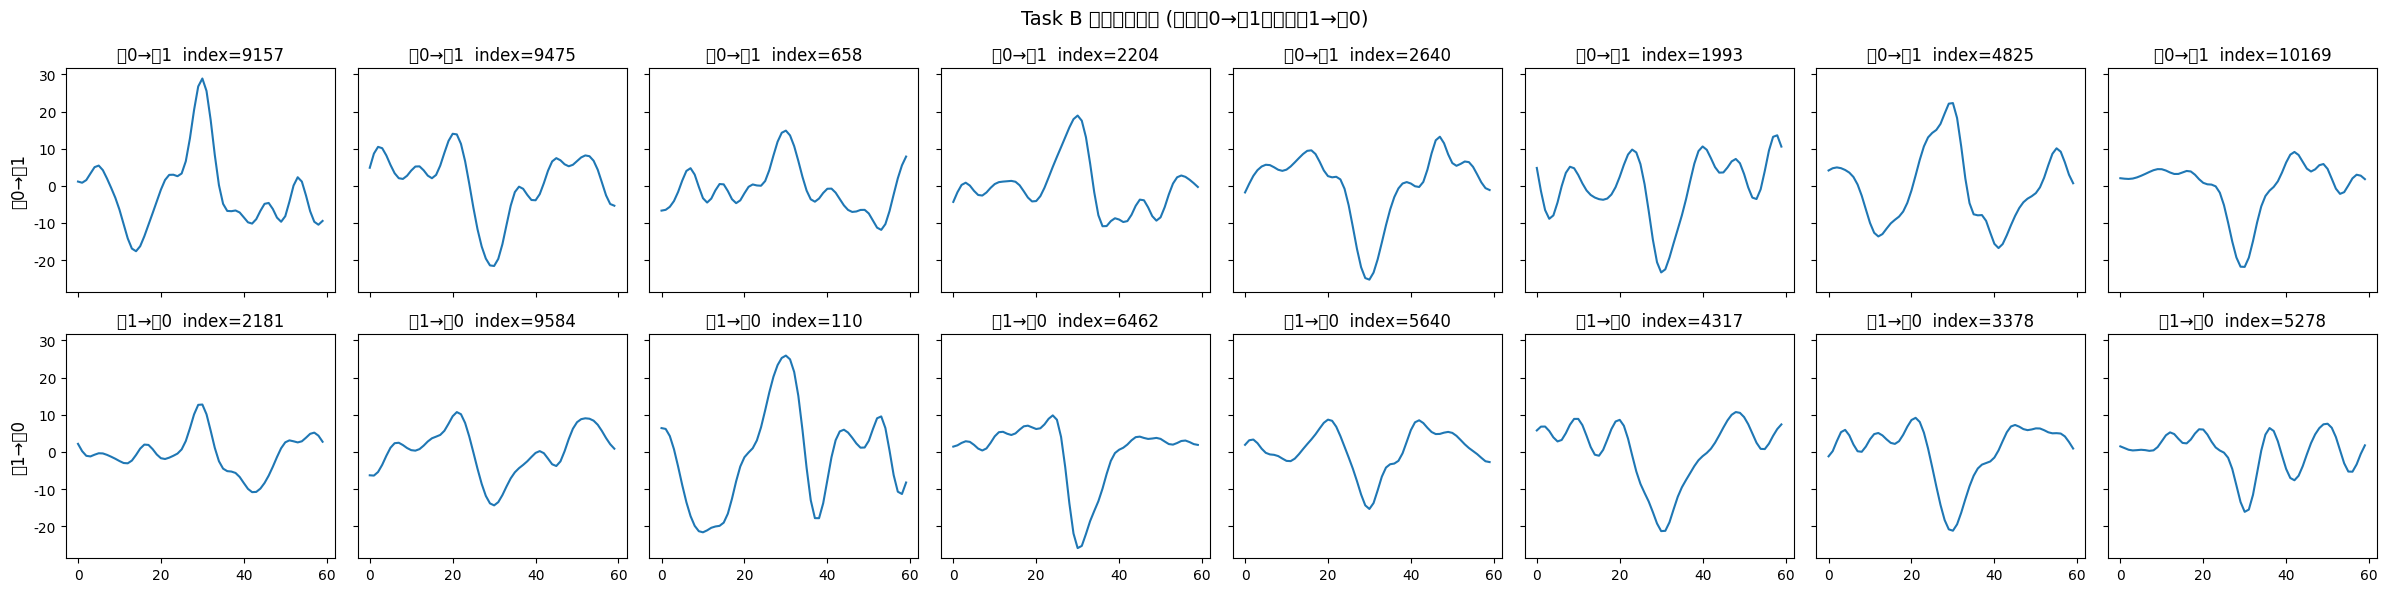

In [30]:
# ===================== Cell: 可视化 Task B 的错分样本 =====================
# 作用：
#   1）加载 Task B 的数据与已训练好的 ResNet1D 模型
#   2）在测试集上做一次预测
#   3）找出两类错误：
#       - 真 0（皮层）但预测为 1（脊髓）
#       - 真 1（脊髓）但预测为 0（皮层）
#   4）分别画在两行，直观看看模型“搞错”的波形长什么样

import os
import numpy as np
import torch
import matplotlib.pyplot as plt
plt.suptitle("Misclassified examples: true 0 vs true 1", fontsize=14)

# -------- 1. 载入 Task B 数据 --------
npz_B_path = os.path.join(Export_FolderName, "taskB_data.npz")
if not os.path.exists(npz_B_path):
    raise FileNotFoundError(f"未找到 {npz_B_path}，请先跑生成 Task B 的 Cell。")

npz_B = np.load(npz_B_path, allow_pickle=True)
Xb, yb = npz_B["X"], npz_B["y"]
trB, vaB, teB = npz_B["tr"], npz_B["val"], npz_B["te"]

print("Task B 数据形状:", Xb.shape, "标签分布:", {k:int(v) for k,v in zip(*np.unique(yb, return_counts=True))})
print("测试集大小:", len(teB))

# -------- 2. 构造测试集张量 --------
X_test = torch.tensor(Xb[teB], dtype=torch.float32).unsqueeze(1)  # (N_test, 1, 60)
y_test = torch.tensor(yb[teB], dtype=torch.long)

# -------- 3. 加载已训练好的 ResNet1D 模型 --------
# 注意：这里假设你之前已经在别的 Cell 定义了 ResNet1D_Small 和 device
# 如果你用的是别的类名(比如 ResNet1D)，把下面这一行改成对应的类名即可。
model_path = "ProcessingTest/resnet1d_taskB_cortex_vs_spinal.pth"

# 1. 重新构建同构网络
model_vis = ResNet1D_Spike(n_classes=2).to(device)

# 2. 加载权重
state = torch.load(model_path, map_location=device)
model_vis.load_state_dict(state)
model_vis.eval()

print("模型已加载用于可视化：", model_path)
print("Task B 模型加载成功！")

# -------- 4. 在测试集上做预测 --------
with torch.no_grad():
    logits = model_vis(X_test.to(device))
    pred_test = logits.argmax(dim=1).cpu().numpy()

y_true = y_test.numpy()

# -------- 5. 找出两类错误样本 --------
#   0 = 皮层（cortex），1 = 脊髓（spinal）
idx_0_to_1 = np.where((y_true == 0) & (pred_test == 1))[0]  # 真0→预1
idx_1_to_0 = np.where((y_true == 1) & (pred_test == 0))[0]  # 真1→预0

print(f"误分情况：真0->预1 数量 = {len(idx_0_to_1)}, 真1->预0 数量 = {len(idx_1_to_0)}")

if len(idx_0_to_1) == 0 and len(idx_1_to_0) == 0:
    print("测试集中没有错分样本，没东西可画。")
else:
    # -------- 6. 随机抽一些错分样本画出来 --------
    n_show = 8  # 每一行最多画几个
    n0 = min(n_show, len(idx_0_to_1))
    n1 = min(n_show, len(idx_1_to_0))

    # 如果某种错分太少，就只画实际数量
    idx_0_to_1_sample = np.random.choice(idx_0_to_1, size=n0, replace=False) if n0 > 0 else []
    idx_1_to_0_sample = np.random.choice(idx_1_to_0, size=n1, replace=False) if n1 > 0 else []

    total_cols = max(n0, n1, 1)

    fig, axes = plt.subplots(2, total_cols, figsize=(3*total_cols, 6), sharex=True, sharey=True)
    if total_cols == 1:
        # 保证 axes 是 2D 数组，方便统一处理
        axes = np.array(axes).reshape(2, 1)

    # 上排：真0→预1
    for col in range(total_cols):
        ax = axes[0, col]
        ax.set_axis_off()
        if col < n0:
            idx = idx_0_to_1_sample[col]
            wave = X_test[idx, 0].cpu().numpy()
            ax.plot(wave)
            ax.set_axis_on()
            ax.set_title(f"真0→预1  index={idx}")
    axes[0, 0].set_ylabel("真0→预1", fontsize=12)

    # 下排：真1→预0
    for col in range(total_cols):
        ax = axes[1, col]
        ax.set_axis_off()
        if col < n1:
            idx = idx_1_to_0_sample[col]
            wave = X_test[idx, 0].cpu().numpy()
            ax.plot(wave)
            ax.set_axis_on()
            ax.set_title(f"真1→预0  index={idx}")
    axes[1, 0].set_ylabel("真1→预0", fontsize=12)

    fig.suptitle("Task B 错分样本波形 (上：真0→预1，下：真1→预0)", fontsize=14)
    plt.tight_layout()
    plt.show()